## 20.3-1

Make a 3-by-3 chart with row and column labels WHITE, GRAY, and
BLACK. In each cell (i, j), indicate whether, at any point during a
depth-first search of a directed graph, there can be an edge from a
vertex of color i to a vertex of color j. For each possible edge, indicate
what edge types it can be. Make a second such chart for depth-first
search of an undirected graph.

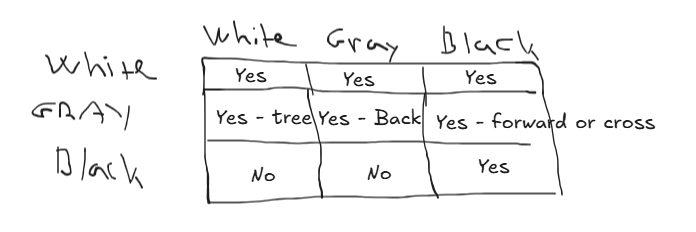
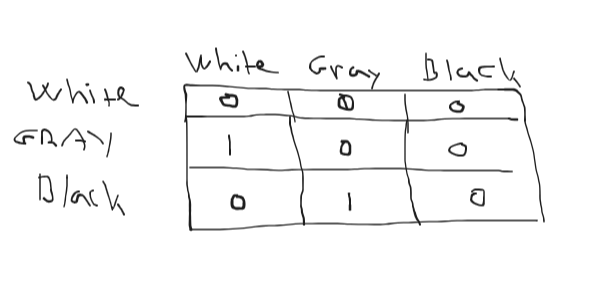
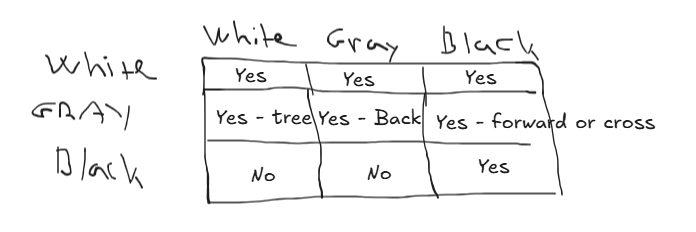

If edge (u→v) exists and u is BLACK (fully finished), then DFS must have visited v during u's
  processing. That means v was discovered and finished before u — so v cannot still be WHITE or GRAY
  after u is BLACK.

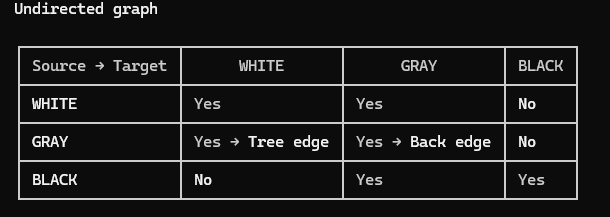

Key differences from directed:
  - GRAY → BLACK is impossible (this would be a forward/cross edge, which Theorem 20.10 proves cannot
  occur in undirected DFS)
  - WHITE → BLACK is impossible (same reasoning as directed: if the edge exists, v would have
  discovered u when v was processed)
  - BLACK → GRAY is possible: if u finished and its ancestor v is still gray — the edge was already
  classified as a back edge when u was gray

## 20.3-2

Show how depth-first search works on the graph of Figure 20.6. Assume
that the for loop of lines 5–7 of the DFS procedure considers the
vertices in alphabetical order, and assume that each adjacency list is
ordered alphabetically. Show the discovery and finish times for each
vertex, and show the classification of each edge.

We start at vertex `q` since that is the first alphabetically we encounter. 

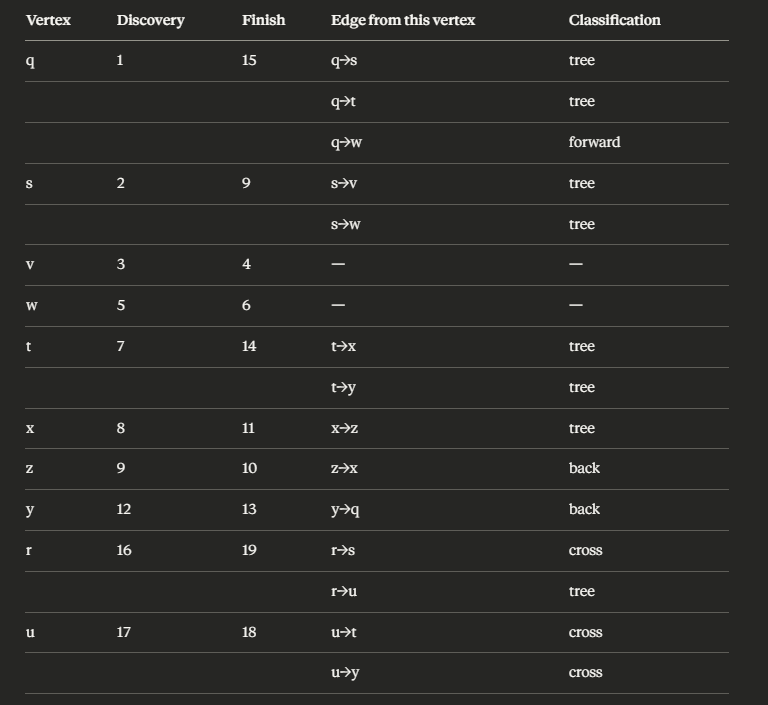

## 20.3-3

Show the parenthesis structure of the depth-first search of Figure 20.4.

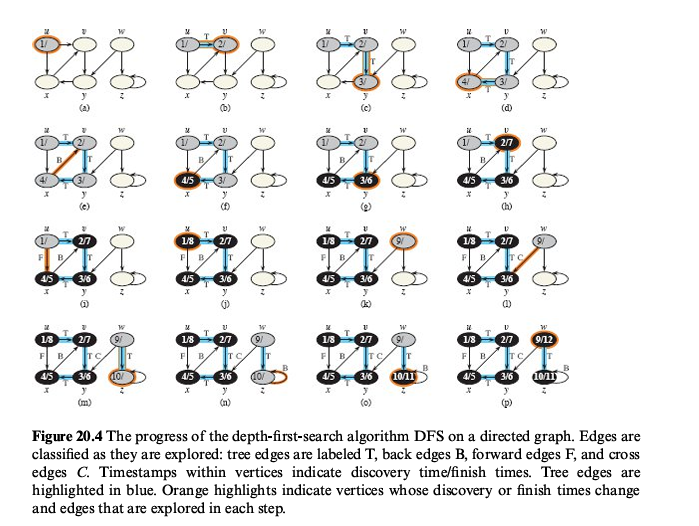

(u (v (y (x x) y) v) u) (w (z z) w)

## 20.3-4

Show that using a single bit to store each vertex color suffices by
arguing that the DFS procedure produces the same result if line 10 of
DFS-VISIT is removed


So with only 1 bit (WHITE vs non-WHITE):

The set of vertices visited is identical
The discovery and finish times are identical
The tree edges are identical
The only thing lost is the ability to classify edges as back vs forward/cross — but the DFS traversal itself is unaffected

## 20.3-5

Show that in a directed graph, edge (u, v) is
* a. a tree edge or forward edge if and only if u.d < v.d < v.f < u.f,
* b. a back edge if and only if v.d ≤ u.d < u.f ≤ v.f, and
* c. a cross edge if and only if v.d < v.f < u.d < u.f

a. Tree or forward edge iff u.d < v.d < v.f < u.f
This condition says v's interval is strictly nested inside u's, meaning v is a descendant of u.
(→) If (u,v) is a tree edge, v was discovered directly from u, so v's entire interval sits inside u's. If (u,v) is a forward edge, v is a non-direct descendant of u, so again v's interval is nested inside u's. In both cases u.d < v.d < v.f < u.f.
(←) If u.d < v.d < v.f < u.f then v is a descendant of u by the parenthesis theorem. When DFS explores (u,v), v is either WHITE, making it a tree edge, or BLACK, making it a forward edge. It cannot be GRAY since that would make v an ancestor of u, contradicting v being a descendant.

b. Back edge iff v.d ≤ u.d < u.f ≤ v.f
This condition says u's interval is nested inside v's, meaning v is an ancestor of u.
(→) If (u,v) is a back edge then v is an ancestor of u, so v was discovered before u and finishes after u, giving v.d < u.d < u.f < v.f. The ≤ instead of < accounts for the self-loop case where u = v, so v.d = u.d and v.f = u.f.
(←) If v.d ≤ u.d < u.f ≤ v.f then u's interval is inside v's, so v is an ancestor of u. When DFS explores (u,v), v must still be GRAY (open on the call stack), which by definition makes (u,v) a back edge.

c. Cross edge iff v.d < v.f < u.d < u.f
This condition says the two intervals are completely disjoint, with v finishing before u is even discovered.
(→) If (u,v) is a cross edge then v is neither an ancestor nor a descendant of u, so their intervals are disjoint by the parenthesis theorem. When DFS explores (u,v), v is already BLACK, meaning v finished before u was discovered, giving v.d < v.f < u.d < u.f.
(←) If v.d < v.f < u.d < u.f then the intervals are disjoint and v finished entirely before u started. When DFS explores (u,v), v is already BLACK and is neither an ancestor nor a descendant of u, which is exactly the definition of a cross edge.

## 20.3-6

Rewrite the procedure DFS, using a stack to eliminate recursion

In [1]:
def DFS(G):
    for u in G.V:
        u.color = WHITE
        u.pi = NIL
    time = 0

    for u in G.V:
        if u.color == WHITE:
            DFS_VISIT(G, u)

def DFS_VISIT(G, u):
    time += 1
    u.d = time
    u.color = GRAY
    stack = [u]

    while stack:
        u = stack[-1]  # peek at top

        # find next unvisited neighbor
        found = False
        for v in G.Adj[u]:
            if v.color == WHITE:
                v.color = GRAY
                v.pi = u
                time += 1
                v.d = time
                stack.append(v)
                found = True
                break

        if not found:
            # no unvisited neighbors, finish this vertex
            stack.pop()
            u.color = "BLACK"
            time += 1
            u.f = timedef DFS(G):
    for u in G.V:
        u.color = "WHITE"
        u.pi = "NIL"
    time = 0

    for u in G.V:
        if u.color == "WHITE":
            DFS_VISIT(G, u)

def DFS_VISIT(G, u):
    time += 1
    u.d = time
    u.color = "GRAY"
    stack = [u]

    while stack:
        u = stack[-1]  # peek at top

        # find next unvisited neighbor
        found = False
        for v in G.Adj[u]:
            if v.color == WHITE:
                v.color = GRAY
                v.pi = u
                time += 1
                v.d = time
                stack.append(v)
                found = True
                break

        if not found:
            # no unvisited neighbors, finish this vertex
            stack.pop()
            u.color = BLACK
            time += 1
            u.f = time

SyntaxError: invalid syntax (2791411744.py, line 37)

## 20.3-7
Give a counterexample to the conjecture that if a directed graph G
contains a path from u to v, and if u.d < v.d in a depth-first search of G,
then v is a descendant of u in the depth-first forest produced.

We need a graph where a path u→...→v exists and u.d < v.d, but v is not a descendant of u in the DFS forest.
Graph:
r → u,  r → v,  u → w,  w → v
DFS visits alphabetically: r first, then r→u (tree), then u→w (tree), but by the time w tries to go to v, DFS already visited v via r→v before exploring w.
VertexDiscoveryFinishr18u25v34w67
Here u.d = 2 < v.d = 3, and a path u→w→v exists, but v is not a descendant of u — it was discovered directly from r before u could reach it through w.
Why the conjecture fails: the existence of a path from u to v in G does not guarantee DFS travels that path. If another vertex discovers v first via a different route, v becomes a descendant of that vertex instead, regardless of any other paths leading to v.

## 20.3-8

Give a counterexample to the conjecture that if a directed graph G
contains a path from u to v, then any depth-first search must result in v.d
≤ u.f

We need a graph where a path u→...→v exists but v.d > u.f, meaning v is discovered after u has already finished.
Graph:
u → w,  r → v,  r → u
With alphabetical DFS order starting at r: r discovers u (tree), u discovers w, both finish, then r discovers v — but by now u has already finished.
VertexDiscoveryFinishr18u25w34v67
Here a path u→w exists but not to v. We need a path from u to v specifically:
Revised graph:
r → u,  r → v,  u → w,  w → x,  x → v  (but r → v is explored before u's subtree reaches v)
Actually the simplest counterexample is:
Graph:
u → v  (only edge), but DFS starts at v before u
DFS visits alphabetically, and if v comes before u alphabetically:
VertexDiscoveryFinishv12u34
Here a path u→v exists, u.d = 3 and v.f = 2, so v.d = 1 < v.f = 2 < u.d = 3 < u.f = 4, meaning v.d < u.f is violated — v was discovered and finished entirely before u was even started.
Why the conjecture fails: if DFS starts at v before it ever reaches u, v will be discovered and finished completely independently. The path u→v in G is never traveled because when DFS eventually reaches u, v is already BLACK and gets skipped, leaving v.f < u.d which directly violates v.d ≤ u.f.


## 20.3-9
Modify the pseudocode for depth-first search so that it prints out every
edge in the directed graph G, together with its type. Show what
modifications, if any, you need to make if G is undirected.

<pre>
DFS-VISIT(G, u)
    time = time + 1
    u.d = time
    u.color = GRAY
    for each v in G.Adj[u]
        if v.color == WHITE
            print "(u,v) is a tree edge"
            v.pi = u
            DFS-VISIT(G, v)
        else if v.color == GRAY
            print "(u,v) is a back edge"
        else if v.d > u.d
            print "(u,v) is a forward edge"
        else
            print "(u,v) is a cross edge"
    u.color = BLACK
    time = time + 1
    u.f = time
 </pre>

## 20.3-10
Explain how a vertex u of a directed graph can end up in a depth-first
tree containing only u, even though u has both incoming and outgoing
edges in G

## 20.3-11

Let G = (V, E) be a connected, undirected graph. Give an O(V + E)
time algorithm to compute a path in G that traverses each edge in E
exactly once in each direction. Describe how you can find your way out
of a maze if you are given a large supply of pennies

Exercise 20.3-10
This happens when all neighbors of u are discovered before u itself, and all vertices that can reach u are also discovered before u.
Concrete example:
Graph: v → u,  u → w
With DFS alphabetical order: u, v, w — but suppose DFS visits in order v, u, w... actually the simplest case is:
Graph: v → u,  u → w
DFS visits alphabetically: u first, then v, then w.
VertexDiscoveryFinishu14w23v56
That puts w as a descendant of u. We need u to be alone. The key is:
Graph: v → u,  u → w
If DFS visits w first, then v, then u:
VertexDiscoveryFinishw12v34u56
Now when DFS reaches u, it tries its outgoing edge u→w but w is already BLACK so it is skipped. u has no other outgoing edges. u also has incoming edge v→u but DFS never follows incoming edges — it only follows outgoing edges in adjacency lists. So u ends up alone in its own tree despite having both an incoming edge from v and an outgoing edge to w.
The general explanation:
A vertex u ends up alone in its own DFS tree when two conditions hold simultaneously:

All vertices reachable from u (via outgoing edges) were already discovered and finished before DFS reached u — so every outgoing edge from u leads to a BLACK vertex and gets classified as a cross edge, giving u no tree children.
All vertices that have edges into u were also already discovered before u — so no other vertex's DFS-VISIT ever reaches u through an outgoing edge, meaning u is never made a tree child of anyone else.

DFS only follows outgoing edges and only recurses into WHITE vertices. Incoming edges are irrelevant to whether u gets discovered — u is only discovered either by the outer DFS loop or by another vertex's outgoing edge pointing to it while it is still WHITE. If neither happens before the outer loop reaches u directly, and all of u's outgoing neighbors are already BLACK, u becomes a one-vertex tree.

## 20.3-12

Show how to use a depth-first search of an undirected graph G to
identify the connected components of G, so that the depth-first forest
contains as many trees as G has connected components. More precisely,
show how to modify depth-first search so that it assigns to each vertex v
an integer label v.cc between 1 and k, where k is the number of
connected components of G, such that u.cc = v.cc if and only if u and v
belong to the same connected component.

<pre>
DFS(G)
    for each vertex u in G.V
        u.color = WHITE
        u.pi = NIL
    time = 0
    cc = 0                          ← component counter
    for each vertex u in G.V
        if u.color == WHITE
            cc = cc + 1             ← new tree = new component
            DFS-VISIT(G, u, cc)

DFS-VISIT(G, u, cc)
    time = time + 1
    u.d = time
    u.color = GRAY
    u.cc = cc                       ← stamp with current component
    for each v in G.Adj[u]
        if v.color == WHITE
            v.pi = u
            DFS-VISIT(G, v, cc)
    u.color = BLACK
    time = time + 1
    u.f = time

</pre

Why this works:
In an undirected graph, DFS-VISIT(G, u) visits every vertex reachable from u before returning. This is exactly the connected component containing u — since the graph is undirected, reachability is symmetric, so every vertex in the same component will be discovered in the same DFS tree. When DFS-VISIT returns to the outer loop and finds another WHITE vertex, that vertex is by definition unreachable from all previously visited vertices, meaning it belongs to a new connected component, so we increment cc.
Correctness of u.cc = v.cc iff u and v are in the same component:

(→) If u and v are in the same component then there is a path between them. DFS-VISIT will discover all of them in the same recursive call tree, stamping them all with the same cc value.
(←) If u.cc = v.cc then both were discovered during the same DFS-VISIT invocation from the outer loop, meaning they are in the same DFS tree. Since the graph is undirected, every edge in the DFS tree is a real edge in G, so u and v are connected.

Note on directed graphs: this does not work for directed graphs because DFS-VISIT only follows outgoing edges, so two vertices in the same strongly connected component might end up in different DFS trees. For directed graphs you would need a separate strongly connected components algorithm such as Kosaraju's or Tarjan's.

In [34]:
from collections import deque

def depth_first_search(graph, start, visited=set()):
    if graph[start]:
        visited.add(start)
        for neighbor in graph[start]:
            if neighbor not in visited:
                print(f'exploring {neighbor} node of vertex {start}')
                visited.add(neighbor)
                depth_first_search(graph, neighbor, visited)

    return visited

In [35]:
graph = {1: [2,3,4],
         2: [3,4],
         3: [4],
         4: [2]}

In [36]:
depth_first_search(graph, 1)

exploring 2 node of vertex 1
exploring 3 node of vertex 2
exploring 4 node of vertex 3


{1, 2, 3, 4}